In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

Matplotlib is building the font cache; this may take a moment.


PyTorch version: 2.12.0


In [2]:
# Problem parameters
kappa = 1.0
R = 1.0
s = 1.0

print(f"kappa = {kappa}")
print(f"R = {R}")
print(f"s = {s}")

kappa = 1.0
R = 1.0
s = 1.0


## Analytical Solution

The analytical solution will be used as the reference solution for all three numerical methods.

In [3]:
def T_exact(r):
    return s * (R**2 - r**2) / (4.0 * kappa)

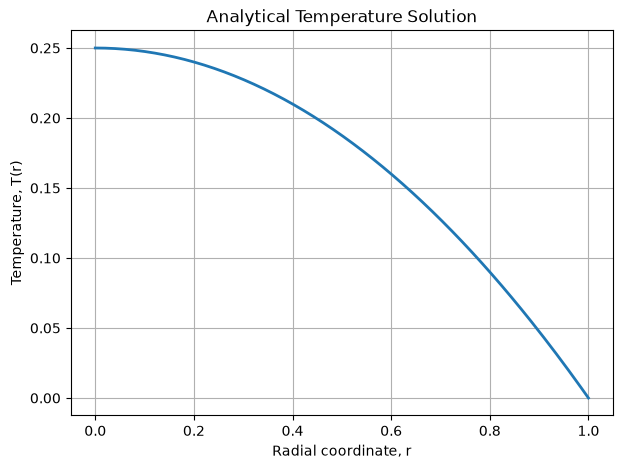

In [4]:
r_plot = np.linspace(0.0, R, 200)
T_plot = T_exact(r_plot)

plt.figure(figsize=(7, 5))
plt.plot(r_plot, T_plot, linewidth=2)

plt.xlabel("Radial coordinate, r")
plt.ylabel("Temperature, T(r)")
plt.title("Analytical Temperature Solution")
plt.grid()
plt.show()

## Part (a): Supervised Neural Network

The neural network is trained using known values of the analytical solution. The network learns the mapping

r → T(r)

from sampled solution data.

In [5]:
# Generate training data
r_train_np = np.linspace(0.0, R, 25).reshape(-1, 1)
T_train_np = T_exact(r_train_np)

# Convert NumPy arrays to PyTorch tensors
r_train = torch.tensor(r_train_np, dtype=torch.float32)
T_train = torch.tensor(T_train_np, dtype=torch.float32)

print("Training input shape:", r_train.shape)
print("Training output shape:", T_train.shape)

Training input shape: torch.Size([25, 1])
Training output shape: torch.Size([25, 1])


In [6]:
class TemperatureNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, r):
        return self.net(r)

In [7]:
model = TemperatureNet()

print(model)

TemperatureNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=1, bias=True)
  )
)


In [8]:
# Mean squared error loss
loss_fn = nn.MSELoss()

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

In [9]:
# Number of training epochs
num_epochs = 5000

# Store loss history
loss_history = []

for epoch in range(num_epochs):

    # Clear previous gradients
    optimizer.zero_grad()

    # Neural-network prediction
    T_pred = model(r_train)

    # Calculate loss
    loss = loss_fn(T_pred, T_train)

    # Backpropagation
    loss.backward()

    # Update network parameters
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    # Print progress
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6e}")

Epoch    0 | Loss = 3.499006e-02
Epoch  500 | Loss = 1.507328e-06
Epoch 1000 | Loss = 9.051317e-07
Epoch 1500 | Loss = 7.835074e-07
Epoch 2000 | Loss = 8.429703e-07
Epoch 2500 | Loss = 9.662740e-07
Epoch 3000 | Loss = 1.163155e-06
Epoch 3500 | Loss = 2.258824e-06
Epoch 4000 | Loss = 1.287173e-05
Epoch 4500 | Loss = 3.853350e-06


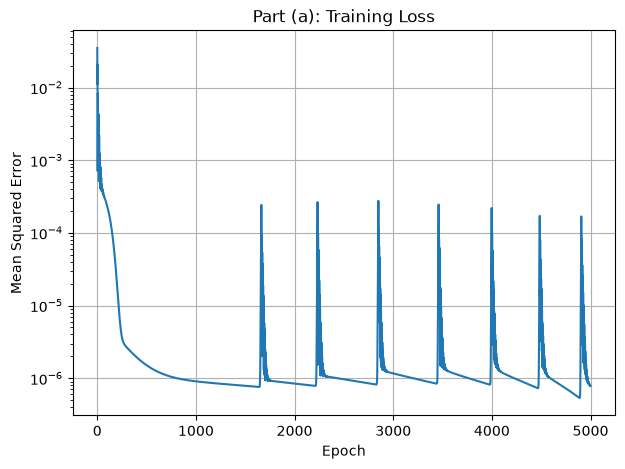

In [10]:
plt.figure(figsize=(7, 5))

plt.semilogy(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Part (a): Training Loss")
plt.grid()
plt.show()

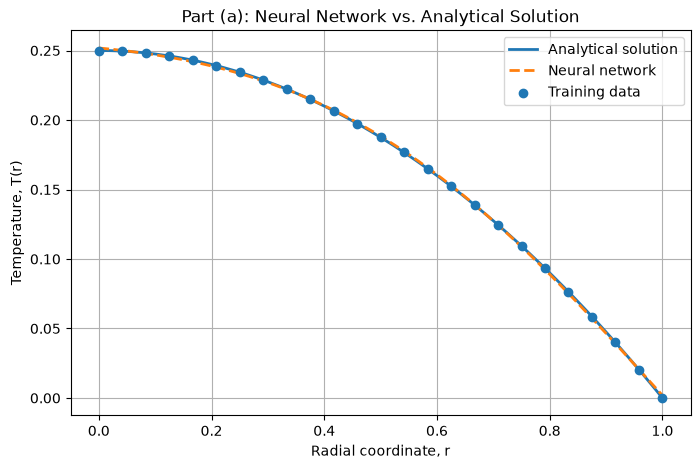

In [11]:
# Dense grid for evaluating the trained network
r_eval_np = np.linspace(0.0, R, 200).reshape(-1, 1)

r_eval = torch.tensor(
    r_eval_np,
    dtype=torch.float32
)

# Evaluate neural network
with torch.no_grad():
    T_nn_np = model(r_eval).numpy()

# Analytical solution
T_exact_np = T_exact(r_eval_np)

# Plot comparison
plt.figure(figsize=(8, 5))

plt.plot(
    r_eval_np,
    T_exact_np,
    label="Analytical solution",
    linewidth=2
)

plt.plot(
    r_eval_np,
    T_nn_np,
    "--",
    label="Neural network",
    linewidth=2
)

plt.scatter(
    r_train_np,
    T_train_np,
    label="Training data",
    zorder=3
)

plt.xlabel("Radial coordinate, r")
plt.ylabel("Temperature, T(r)")
plt.title("Part (a): Neural Network vs. Analytical Solution")
plt.legend()
plt.grid()
plt.show()

In [12]:
# Relative L2 error
relative_L2_error = (
    np.linalg.norm(T_nn_np - T_exact_np)
    / np.linalg.norm(T_exact_np)
)

# Maximum absolute error
max_absolute_error = np.max(
    np.abs(T_nn_np - T_exact_np)
)

print(f"Relative L2 error: {relative_L2_error:.6e}")
print(f"Maximum absolute error: {max_absolute_error:.6e}")

Relative L2 error: 4.402099e-03
Maximum absolute error: 1.861677e-03


## Part (b): Physics-Informed Neural Network

Instead of training on known temperature values, the PINN is trained by minimizing the governing differential-equation residual and the boundary-condition errors.

The governing equation is

κ d/dr(r dT/dr) + rs = 0

with boundary conditions

dT/dr = 0 at r = 0

T(R) = 0.

In [13]:
pinn = TemperatureNet()

print(pinn)

TemperatureNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=1, bias=True)
  )
)


In [14]:
def derivative(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

In [15]:
# Collocation points for enforcing the PDE
r_col = torch.linspace(
    0.0,
    R,
    100
).reshape(-1, 1)

# Required for automatic differentiation
r_col.requires_grad_(True)

tensor([[0.0000],
        [0.0101],
        [0.0202],
        [0.0303],
        [0.0404],
        [0.0505],
        [0.0606],
        [0.0707],
        [0.0808],
        [0.0909],
        [0.1010],
        [0.1111],
        [0.1212],
        [0.1313],
        [0.1414],
        [0.1515],
        [0.1616],
        [0.1717],
        [0.1818],
        [0.1919],
        [0.2020],
        [0.2121],
        [0.2222],
        [0.2323],
        [0.2424],
        [0.2525],
        [0.2626],
        [0.2727],
        [0.2828],
        [0.2929],
        [0.3030],
        [0.3131],
        [0.3232],
        [0.3333],
        [0.3434],
        [0.3535],
        [0.3636],
        [0.3737],
        [0.3838],
        [0.3939],
        [0.4040],
        [0.4141],
        [0.4242],
        [0.4343],
        [0.4444],
        [0.4545],
        [0.4646],
        [0.4747],
        [0.4848],
        [0.4949],
        [0.5051],
        [0.5152],
        [0.5253],
        [0.5354],
        [0.5455],
        [0

In [16]:
T_pinn = pinn(r_col)

dTdr = derivative(T_pinn, r_col)

r_dTdr = r_col * dTdr

residual = (
    kappa * derivative(r_dTdr, r_col)
    + r_col * s
)

In [17]:
loss_pde = torch.mean(residual**2)

print("Initial PDE loss:", loss_pde.item())

Initial PDE loss: 0.2534792721271515


In [18]:
r0 = torch.tensor(
    [[0.0]],
    dtype=torch.float32,
    requires_grad=True
)

T0 = pinn(r0)

dTdr0 = derivative(T0, r0)

loss_bc0 = torch.mean(dTdr0**2)

In [19]:
rR = torch.tensor(
    [[R]],
    dtype=torch.float32
)

TR = pinn(rR)

loss_bcR = torch.mean(TR**2)

In [20]:
lambda_0 = 1.0
lambda_R = 1.0

loss = (
    loss_pde
    + lambda_0 * loss_bc0
    + lambda_R * loss_bcR
)

print("Initial total loss:", loss.item())

Initial total loss: 0.27715200185775757


In [21]:
pinn_optimizer = torch.optim.Adam(
    pinn.parameters(),
    lr=0.01
)

In [22]:
num_epochs_pinn = 5000

pinn_loss_history = []
pde_loss_history = []
bc0_loss_history = []
bcR_loss_history = []

for epoch in range(num_epochs_pinn):

    pinn_optimizer.zero_grad()

    # Network prediction
    T_pinn = pinn(r_col)

    # First derivative
    dTdr = derivative(T_pinn, r_col)

    # r * dT/dr
    r_dTdr = r_col * dTdr

    # PDE residual
    residual = (
        kappa * derivative(r_dTdr, r_col)
        + r_col * s
    )

    # PDE loss
    loss_pde = torch.mean(residual**2)

    # Center BC
    T0 = pinn(r0)
    dTdr0 = derivative(T0, r0)
    loss_bc0 = torch.mean(dTdr0**2)

    # Outer BC
    TR = pinn(rR)
    loss_bcR = torch.mean(TR**2)

    # Total loss
    loss = (
        loss_pde
        + lambda_0 * loss_bc0
        + lambda_R * loss_bcR
    )

    # Backpropagation
    loss.backward()

    # Update model
    pinn_optimizer.step()

    # Save losses
    pinn_loss_history.append(loss.item())
    pde_loss_history.append(loss_pde.item())
    bc0_loss_history.append(loss_bc0.item())
    bcR_loss_history.append(loss_bcR.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total = {loss.item():.6e} | "
            f"PDE = {loss_pde.item():.6e} | "
            f"BC0 = {loss_bc0.item():.6e} | "
            f"BCR = {loss_bcR.item():.6e}"
        )

Epoch    0 | Total = 2.771520e-01 | PDE = 2.534793e-01 | BC0 = 9.619422e-03 | BCR = 1.405331e-02
Epoch  500 | Total = 6.530591e-06 | PDE = 5.981719e-06 | BC0 = 5.487571e-07 | BCR = 1.146288e-10
Epoch 1000 | Total = 4.299738e-04 | PDE = 6.707622e-05 | BC0 = 2.824818e-05 | BCR = 3.346494e-04
Epoch 1500 | Total = 7.673025e-06 | PDE = 3.837778e-06 | BC0 = 9.453688e-09 | BCR = 3.825794e-06
Epoch 2000 | Total = 6.781834e-07 | PDE = 6.600060e-07 | BC0 = 1.390696e-08 | BCR = 4.270497e-09
Epoch 2500 | Total = 6.577659e-07 | PDE = 6.432479e-07 | BC0 = 1.451803e-08 | BCR = 4.996004e-16
Epoch 3000 | Total = 6.912171e-07 | PDE = 6.770094e-07 | BC0 = 1.420730e-08 | BCR = 2.798317e-13
Epoch 3500 | Total = 7.215996e-07 | PDE = 7.076676e-07 | BC0 = 1.393158e-08 | BCR = 4.801159e-13
Epoch 4000 | Total = 7.414207e-07 | PDE = 7.286762e-07 | BC0 = 1.274442e-08 | BCR = 3.197442e-14
Epoch 4500 | Total = 6.536752e-05 | PDE = 4.240096e-06 | BC0 = 3.312447e-06 | BCR = 5.781497e-05


In [23]:
num_epochs_pinn = 5000

pinn_loss_history = []
pde_loss_history = []
bc0_loss_history = []
bcR_loss_history = []

for epoch in range(num_epochs_pinn):

    pinn_optimizer.zero_grad()

    # Network prediction
    T_pinn = pinn(r_col)

    # First derivative
    dTdr = derivative(T_pinn, r_col)

    # r * dT/dr
    r_dTdr = r_col * dTdr

    # PDE residual
    residual = (
        kappa * derivative(r_dTdr, r_col)
        + r_col * s
    )

    # PDE loss
    loss_pde = torch.mean(residual**2)

    # Center BC
    T0 = pinn(r0)
    dTdr0 = derivative(T0, r0)
    loss_bc0 = torch.mean(dTdr0**2)

    # Outer BC
    TR = pinn(rR)
    loss_bcR = torch.mean(TR**2)

    # Total loss
    loss = (
        loss_pde
        + lambda_0 * loss_bc0
        + lambda_R * loss_bcR
    )

    # Backpropagation
    loss.backward()

    # Update model
    pinn_optimizer.step()

    # Save losses
    pinn_loss_history.append(loss.item())
    pde_loss_history.append(loss_pde.item())
    bc0_loss_history.append(loss_bc0.item())
    bcR_loss_history.append(loss_bcR.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total = {loss.item():.6e} | "
            f"PDE = {loss_pde.item():.6e} | "
            f"BC0 = {loss_bc0.item():.6e} | "
            f"BCR = {loss_bcR.item():.6e}"
        )

Epoch    0 | Total = 5.947590e-05 | PDE = 3.999533e-06 | BC0 = 3.478390e-06 | BCR = 5.199798e-05
Epoch  500 | Total = 7.896123e-07 | PDE = 7.618890e-07 | BC0 = 1.399497e-08 | BCR = 1.372830e-08
Epoch 1000 | Total = 1.171673e-06 | PDE = 8.072598e-07 | BC0 = 8.219594e-08 | BCR = 2.822173e-07
Epoch 1500 | Total = 9.849251e-07 | PDE = 7.859141e-07 | BC0 = 4.901860e-08 | BCR = 1.499925e-07
Epoch 2000 | Total = 7.761255e-06 | PDE = 5.253085e-06 | BC0 = 1.255671e-10 | BCR = 2.508044e-06
Epoch 2500 | Total = 6.700783e-07 | PDE = 6.065263e-07 | BC0 = 5.459242e-10 | BCR = 6.300605e-08
Epoch 3000 | Total = 5.066062e-07 | PDE = 4.683647e-07 | BC0 = 1.355773e-08 | BCR = 2.468368e-08
Epoch 3500 | Total = 4.789351e-07 | PDE = 4.477619e-07 | BC0 = 5.653725e-09 | BCR = 2.551939e-08
Epoch 4000 | Total = 4.024135e-07 | PDE = 3.422643e-07 | BC0 = 2.494893e-10 | BCR = 5.989968e-08
Epoch 4500 | Total = 1.701336e-05 | PDE = 9.321016e-06 | BC0 = 9.261113e-07 | BCR = 6.766235e-06


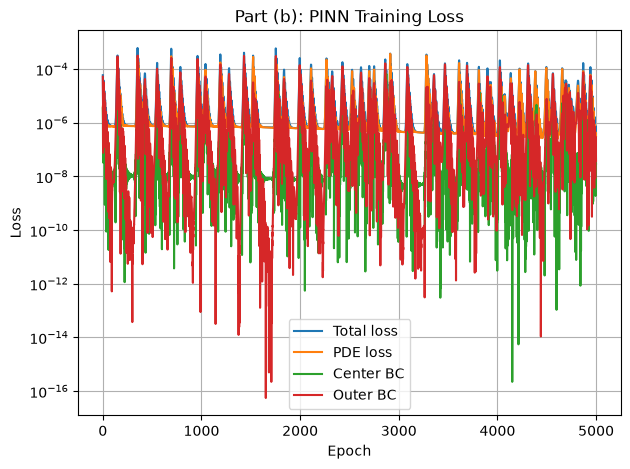

In [24]:
plt.figure(figsize=(7, 5))

plt.semilogy(
    pinn_loss_history,
    label="Total loss"
)

plt.semilogy(
    pde_loss_history,
    label="PDE loss"
)

plt.semilogy(
    bc0_loss_history,
    label="Center BC"
)

plt.semilogy(
    bcR_loss_history,
    label="Outer BC"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part (b): PINN Training Loss")
plt.legend()
plt.grid()

plt.show()

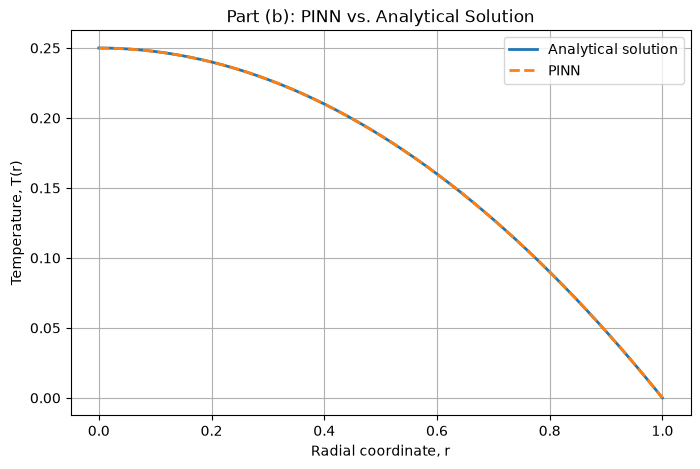

In [25]:
# Evaluate the trained PINN on a dense grid
r_pinn_np = np.linspace(0.0, R, 200).reshape(-1, 1)

r_pinn = torch.tensor(
    r_pinn_np,
    dtype=torch.float32,
    requires_grad=True
)

# PINN prediction
T_pinn_pred = pinn(r_pinn)

# Analytical solution
T_exact_pinn = T_exact(r_pinn_np)

# Convert PINN prediction to NumPy
T_pinn_np = T_pinn_pred.detach().numpy()

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    r_pinn_np,
    T_exact_pinn,
    label="Analytical solution",
    linewidth=2
)

plt.plot(
    r_pinn_np,
    T_pinn_np,
    "--",
    label="PINN",
    linewidth=2
)

plt.xlabel("Radial coordinate, r")
plt.ylabel("Temperature, T(r)")
plt.title("Part (b): PINN vs. Analytical Solution")
plt.legend()
plt.grid()

plt.show()

In [26]:
# Relative L2 error
relative_L2_error_pinn = (
    np.linalg.norm(T_pinn_np - T_exact_pinn)
    / np.linalg.norm(T_exact_pinn)
)

# Maximum absolute error
max_error_pinn = np.max(
    np.abs(T_pinn_np - T_exact_pinn)
)

print(f"PINN relative L2 error: {relative_L2_error_pinn:.6e}")
print(f"PINN maximum absolute error: {max_error_pinn:.6e}")

PINN relative L2 error: 2.213677e-04
PINN maximum absolute error: 7.703900e-05


In [27]:
# Center boundary condition
r0_check = torch.tensor(
    [[0.0]],
    dtype=torch.float32,
    requires_grad=True
)

T0_check = pinn(r0_check)

dTdr0_check = derivative(
    T0_check,
    r0_check
)

print(
    f"dT/dr at r=0 = {dTdr0_check.item():.6e}"
)

dT/dr at r=0 = -1.736283e-04


In [28]:
# Outer boundary condition
rR_check = torch.tensor(
    [[R]],
    dtype=torch.float32
)

TR_check = pinn(rR_check)

print(
    f"T(R) = {TR_check.item():.6e}"
)

T(R) = -7.706881e-05


In [29]:
# Calculate PDE residual on dense grid

r_res = torch.linspace(
    0.0,
    R,
    200
).reshape(-1, 1)

r_res.requires_grad_(True)

T_res = pinn(r_res)

dTdr_res = derivative(
    T_res,
    r_res
)

r_dTdr_res = r_res * dTdr_res

residual_res = (
    kappa * derivative(
        r_dTdr_res,
        r_res
    )
    + r_res * s
)

residual_np = residual_res.detach().numpy()
r_res_np = r_res.detach().numpy()

In [30]:
residual_norm = np.sqrt(
    np.mean(residual_np**2)
)

maximum_residual = np.max(
    np.abs(residual_np)
)

print(f"RMS PDE residual = {residual_norm:.6e}")
print(f"Maximum |PDE residual| = {maximum_residual:.6e}")

RMS PDE residual = 5.068292e-04
Maximum |PDE residual| = 1.338482e-03


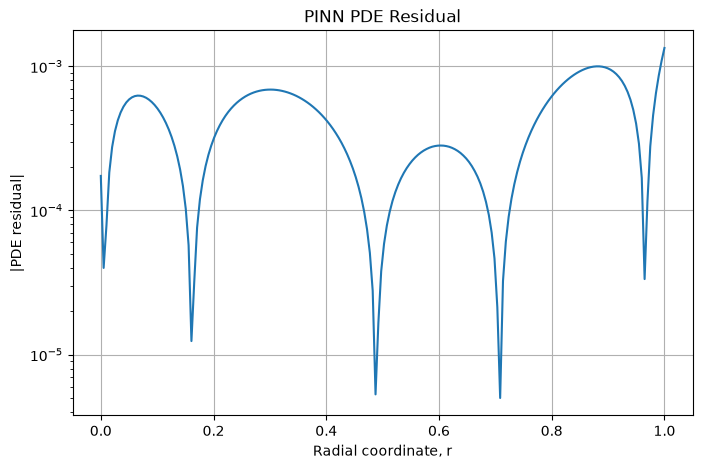

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    r_res_np,
    np.abs(residual_np)
)

plt.xlabel("Radial coordinate, r")
plt.ylabel("|PDE residual|")
plt.title("PINN PDE Residual")
plt.yscale("log")
plt.grid()

plt.show()

## Part (c): Finite-Difference Solution

The same radial heat-conduction problem is solved using a finite-difference discretization.

The domain [0,R] is divided into N uniform intervals. The finite-difference solution is then compared with the analytical solution and checked for mesh convergence.

In [32]:
def solve_finite_difference(N):
    
    # Create grid
    r = np.linspace(0.0, R, N + 1)
    dr = r[1] - r[0]

    # Initialize linear system A*T = b
    A = np.zeros((N + 1, N + 1))
    b = np.zeros(N + 1)

    # ------------------------------------------------
    # Center boundary condition:
    # dT/dr = 0 at r = 0
    #
    # (-3T0 + 4T1 - T2)/(2dr) = 0
    # ------------------------------------------------
    
    A[0, 0] = -3.0
    A[0, 1] = 4.0
    A[0, 2] = -1.0

    # ------------------------------------------------
    # Interior nodes
    #
    # kappa [ r_i T'' + T' ] + r_i*s = 0
    # ------------------------------------------------
    
    for i in range(1, N):
        
        ri = r[i]

        # Coefficient of T_(i-1)
        A[i, i-1] = (
            kappa * (
                ri / dr**2
                - 1.0 / (2.0 * dr)
            )
        )

        # Coefficient of T_i
        A[i, i] = (
            kappa * (
                -2.0 * ri / dr**2
            )
        )

        # Coefficient of T_(i+1)
        A[i, i+1] = (
            kappa * (
                ri / dr**2
                + 1.0 / (2.0 * dr)
            )
        )

        # Right-hand side
        b[i] = -ri * s

    # ------------------------------------------------
    # Outer boundary condition:
    # T(R) = 0
    # ------------------------------------------------
    
    A[N, N] = 1.0
    b[N] = 0.0

    # Solve linear system
    T_fd = np.linalg.solve(A, b)

    return r, T_fd

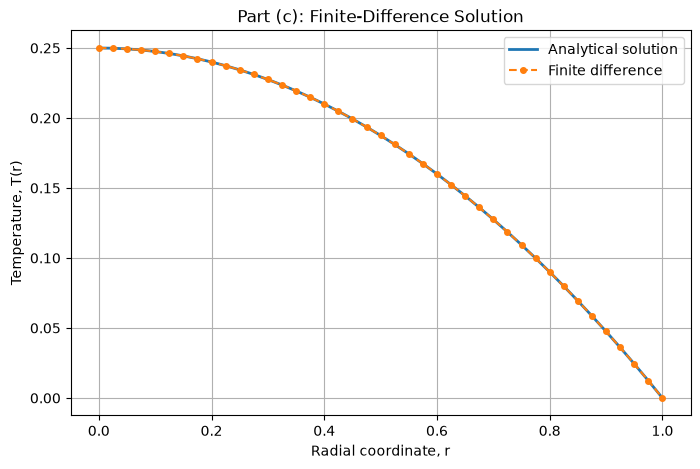

In [33]:
N = 40

r_fd, T_fd = solve_finite_difference(N)

T_exact_fd = T_exact(r_fd)

plt.figure(figsize=(8, 5))

plt.plot(
    r_fd,
    T_exact_fd,
    label="Analytical solution",
    linewidth=2
)

plt.plot(
    r_fd,
    T_fd,
    "o--",
    label="Finite difference",
    markersize=4
)

plt.xlabel("Radial coordinate, r")
plt.ylabel("Temperature, T(r)")
plt.title("Part (c): Finite-Difference Solution")
plt.legend()
plt.grid()

plt.show()

In [34]:
relative_L2_fd = (
    np.linalg.norm(T_fd - T_exact_fd)
    / np.linalg.norm(T_exact_fd)
)

max_error_fd = np.max(
    np.abs(T_fd - T_exact_fd)
)

print(f"Finite-difference relative L2 error: {relative_L2_fd:.6e}")
print(f"Finite-difference maximum absolute error: {max_error_fd:.6e}")

Finite-difference relative L2 error: 2.247364e-15
Finite-difference maximum absolute error: 6.106227e-16


In [35]:
# Mesh refinement study

N_values = [10, 20, 40, 80]

fd_errors = []
dr_values = []

for N in N_values:
    
    r_fd, T_fd = solve_finite_difference(N)
    
    T_exact_fd = T_exact(r_fd)
    
    error = (
        np.linalg.norm(T_fd - T_exact_fd)
        / np.linalg.norm(T_exact_fd)
    )
    
    dr = r_fd[1] - r_fd[0]
    
    fd_errors.append(error)
    dr_values.append(dr)

    print(
        f"N = {N:3d} | "
        f"dr = {dr:.6f} | "
        f"Relative L2 error = {error:.6e}"
    )

N =  10 | dr = 0.100000 | Relative L2 error = 9.867683e-16
N =  20 | dr = 0.050000 | Relative L2 error = 3.349798e-15
N =  40 | dr = 0.025000 | Relative L2 error = 2.247364e-15
N =  80 | dr = 0.012500 | Relative L2 error = 3.065948e-14


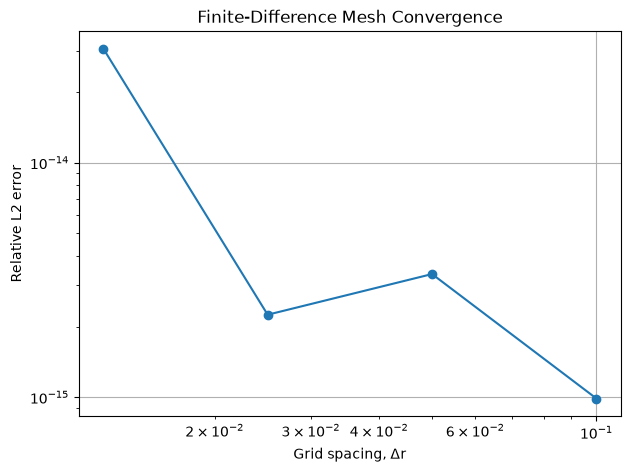

In [36]:
plt.figure(figsize=(7, 5))

plt.loglog(
    dr_values,
    fd_errors,
    "o-"
)

plt.xlabel("Grid spacing, Δr")
plt.ylabel("Relative L2 error")
plt.title("Finite-Difference Mesh Convergence")
plt.grid()

plt.show()

## Final Comparison

The analytical solution, supervised neural network, physics-informed neural network, and finite-difference solution are compared using the same parameters and radial domain.

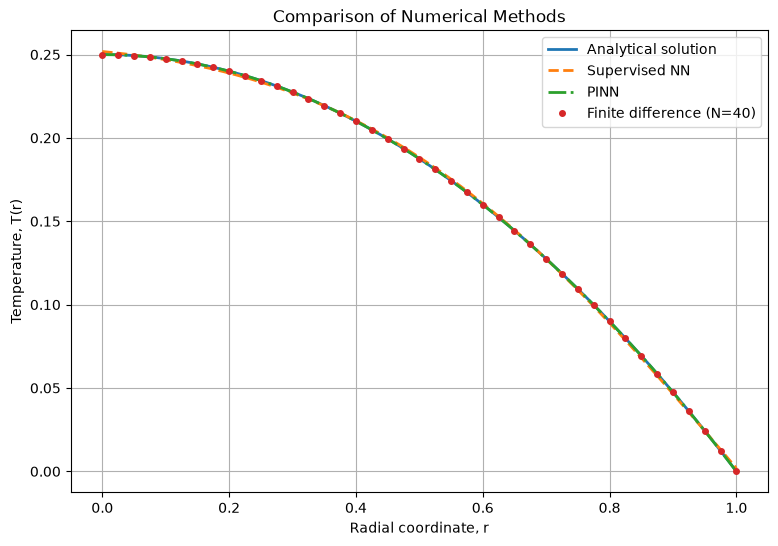

In [37]:
# ---------------------------------------------------------
# Final comparison of all four solutions
# ---------------------------------------------------------

# Dense evaluation grid
r_compare_np = np.linspace(0.0, R, 300).reshape(-1, 1)

# Analytical solution
T_compare_exact = T_exact(r_compare_np)

# Supervised NN
r_compare_torch = torch.tensor(
    r_compare_np,
    dtype=torch.float32
)

with torch.no_grad():
    T_compare_nn = model(r_compare_torch).numpy()

# PINN
with torch.no_grad():
    T_compare_pinn = pinn(r_compare_torch).numpy()

# Finite difference solution
r_fd_compare, T_fd_compare = solve_finite_difference(40)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    r_compare_np,
    T_compare_exact,
    label="Analytical solution",
    linewidth=2
)

plt.plot(
    r_compare_np,
    T_compare_nn,
    "--",
    label="Supervised NN",
    linewidth=2
)

plt.plot(
    r_compare_np,
    T_compare_pinn,
    "-.",
    label="PINN",
    linewidth=2
)

plt.plot(
    r_fd_compare,
    T_fd_compare,
    "o",
    label="Finite difference (N=40)",
    markersize=4
)

plt.xlabel("Radial coordinate, r")
plt.ylabel("Temperature, T(r)")
plt.title("Comparison of Numerical Methods")
plt.legend()
plt.grid()

plt.show()

In [38]:
# Calculate errors for all three numerical methods

# Supervised NN
nn_relative_L2 = (
    np.linalg.norm(T_compare_nn - T_compare_exact)
    / np.linalg.norm(T_compare_exact)
)

# PINN
pinn_relative_L2 = (
    np.linalg.norm(T_compare_pinn - T_compare_exact)
    / np.linalg.norm(T_compare_exact)
)

# Finite difference
T_exact_fd_compare = T_exact(r_fd_compare)

fd_relative_L2 = (
    np.linalg.norm(T_fd_compare - T_exact_fd_compare)
    / np.linalg.norm(T_exact_fd_compare)
)

print("Relative L2 Errors")
print("-----------------------------")
print(f"Supervised NN : {nn_relative_L2:.6e}")
print(f"PINN          : {pinn_relative_L2:.6e}")
print(f"Finite diff.  : {fd_relative_L2:.6e}")

Relative L2 Errors
-----------------------------
Supervised NN : 4.385061e-03
PINN          : 2.209300e-04
Finite diff.  : 2.247364e-15


### Discussion

The three methods all produced temperature profiles that closely followed the analytical solution. The supervised neural network was trained from sampled solution data and gave a relative L2 error of 4.39 × 10^-3. The PINN instead used the governing equation and boundary conditions during training and achieved a relative L2 error of 2.21 × 10^-4. The finite-difference solution matched the analytical result to approximately machine precision, with a relative L2 error of 2.25 × 10^-15 for N = 40.

The finite-difference mesh study also showed errors on the order of 10^-15 for all tested mesh sizes. Since the analytical solution is quadratic in r, the finite-difference formulation can represent the solution very accurately, making roundoff error the primary limitation.

The main difference between the methods is how the solution is obtained. The supervised neural network relies on known temperature data, the PINN learns by enforcing the governing physics and boundary conditions, and the finite-difference method directly discretizes the differential equation and solves the resulting system. Despite these differences, all three approaches produced solutions that closely matched the analytical result for this problem.

## Procedure

The radial heat-conduction problem was solved using three numerical approaches and compared with the analytical solution. First, the analytical solution was calculated and used as the reference for evaluating the numerical results.

For the supervised neural network, temperature data were generated from the analytical solution at 25 radial locations. A feed-forward neural network with two hidden layers of 20 neurons and hyperbolic tangent activation functions was trained using mean-squared error and the Adam optimizer.

For the physics-informed neural network, a separate neural network with the same architecture was trained without using analytical temperature data. Instead, automatic differentiation was used to calculate the derivatives required for the governing differential equation. The training loss included the PDE residual and the two boundary-condition errors.

Finally, the governing equation was discretized using a finite-difference method. Centered finite differences were used at interior nodes, while the boundary conditions were applied at the center and outer radius. Solutions were calculated for multiple mesh sizes to evaluate mesh convergence.

The results from all three methods were compared with the analytical solution using relative L2 error. The PINN was additionally evaluated using its boundary-condition errors and PDE residual.